In [6]:
'''
This script analyzes the comparison between simulation and real-world data from CSV files.
'''


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# read data from the files
sim_states = pd.read_csv('denormalized_states.csv')
real_imu = pd.read_csv('imu.csv')
real_joints = pd.read_csv('DXL_cur.csv')

# set up the read data
sim_imu = sim_states.iloc[:, 0:3]
sim_joints = sim_states.iloc[:, 3:21]
# real imu: deg to rad
real_imu = real_imu.iloc[110:500, :]
real_joints = real_joints.iloc[110:500, :]
real_imu = real_imu * np.pi / 180.0
# offset removal for real imu
real_imu = real_imu - real_imu.iloc[0, :]

dir_conv = np.array([
            [-1.0,  1.0,  1.0],  # LF_ThC, LF_CTr, LF_FTi
            [-1.0,  1.0,  1.0],  # LM_ThC, LM_CTr, LM_FTi
            [-1.0,  1.0,  1.0],  # LH_ThC, LH_CTr, LH_FTi
            [-1.0,  1.0,  1.0],  # RF_ThC, RF_CTr, RF_FTi
            [-1.0,  1.0,  1.0],  # RM_ThC, RM_CTr, RM_FTi
            [-1.0,  1.0,  1.0],  # RH_ThC, RH_CTr, RH_FTi
        ], dtype=np.float32).reshape(-1)  # (18,)
real_joints = real_joints * dir_conv  # remove time column and apply direction conversion

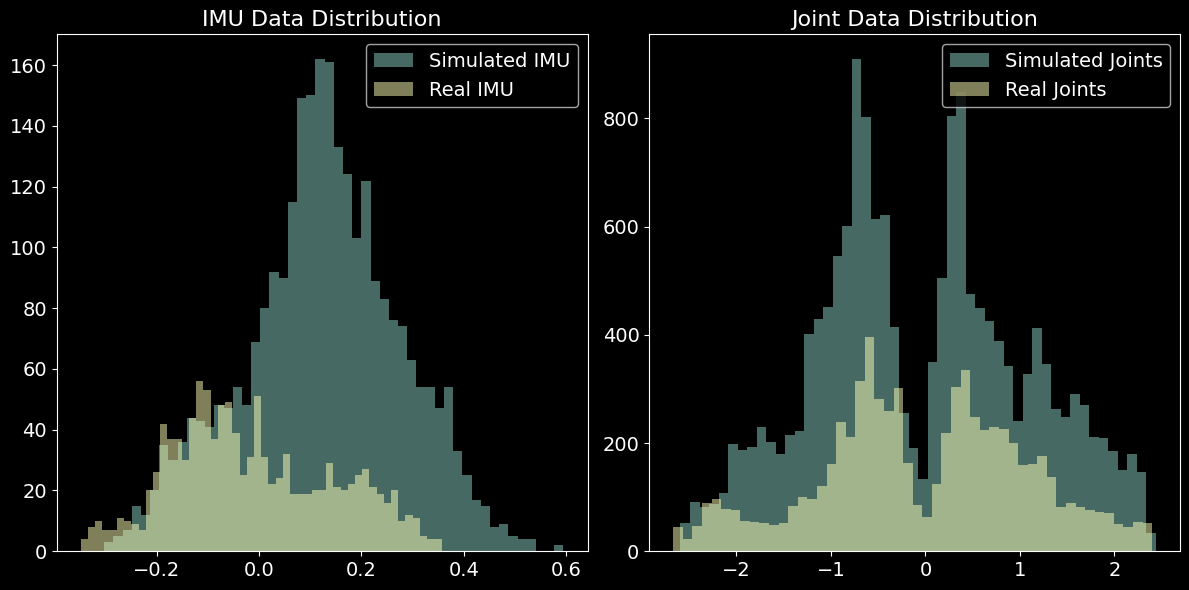

In [7]:
# plot the histogram
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs = axs.ravel()
axs[0].hist(sim_imu.values.flatten(), bins=50, alpha=0.5, label='Simulated IMU')
axs[0].hist(real_imu.values.flatten(), bins=50, alpha=0.5, label='Real IMU')
axs[0].set_title('IMU Data Distribution', fontsize =16)
axs[0].legend(fontsize=14)
axs[1].hist(sim_joints.values.flatten(), bins=50, alpha=0.5, label='Simulated Joints')
axs[1].hist(real_joints.values.flatten(), bins=50, alpha=0.5, label='Real Joints')
axs[1].set_title('Joint Data Distribution', fontsize =16)
axs[1].legend(fontsize=14)
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

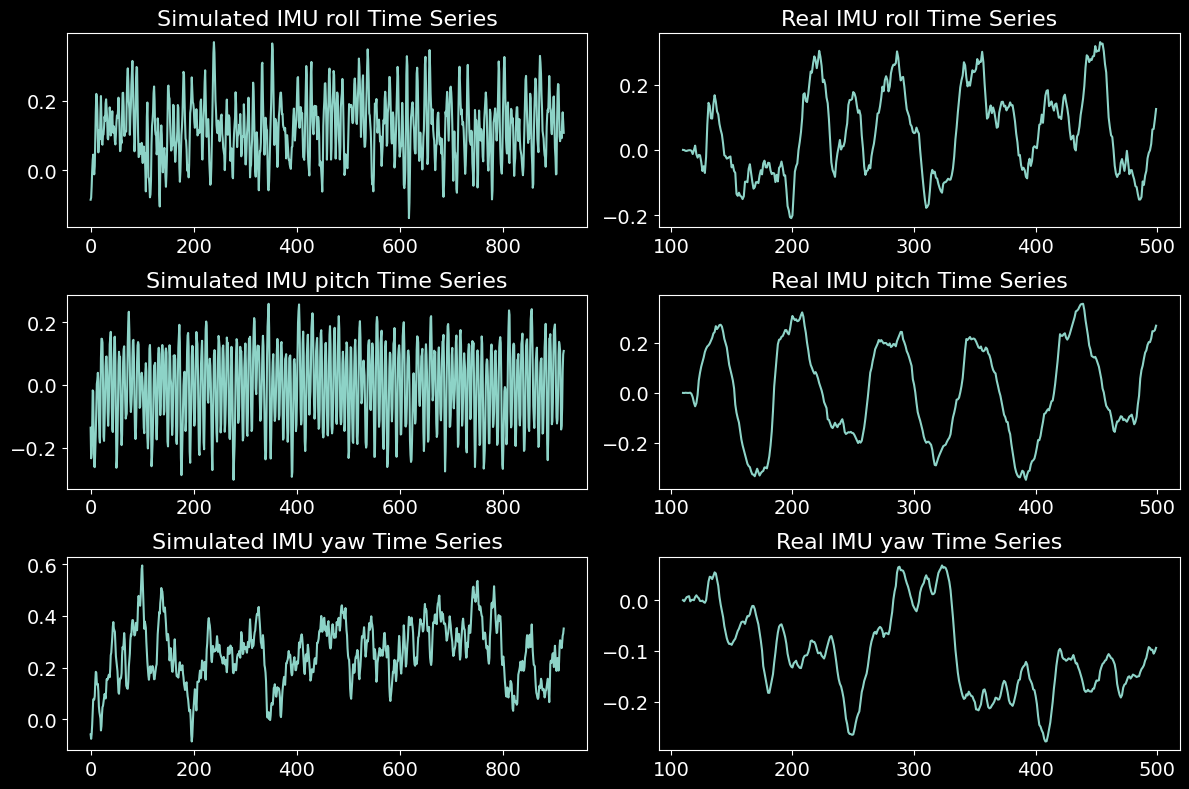

In [8]:
# plot the time series
fig, axs = plt.subplots(3, 2, figsize=(12, 8))
axs = axs.ravel()
axs[0].plot(sim_imu.index, sim_imu.iloc[:,0])
axs[0].set_title('Simulated IMU roll Time Series', fontsize =16)
axs[1].plot(real_imu.index, real_imu.iloc[:,0])
axs[1].set_title('Real IMU roll Time Series', fontsize =16)
axs[2].plot(sim_imu.index, sim_imu.iloc[:,1])
axs[2].set_title('Simulated IMU pitch Time Series', fontsize =16)
axs[3].plot(real_imu.index, real_imu.iloc[:,1])
axs[3].set_title('Real IMU pitch Time Series', fontsize =16)
axs[4].plot(sim_imu.index, sim_imu.iloc[:,2])
axs[4].set_title('Simulated IMU yaw Time Series', fontsize =16)
axs[5].plot(real_imu.index, real_imu.iloc[:,2])
axs[5].set_title('Real IMU yaw Time Series', fontsize =16)
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()


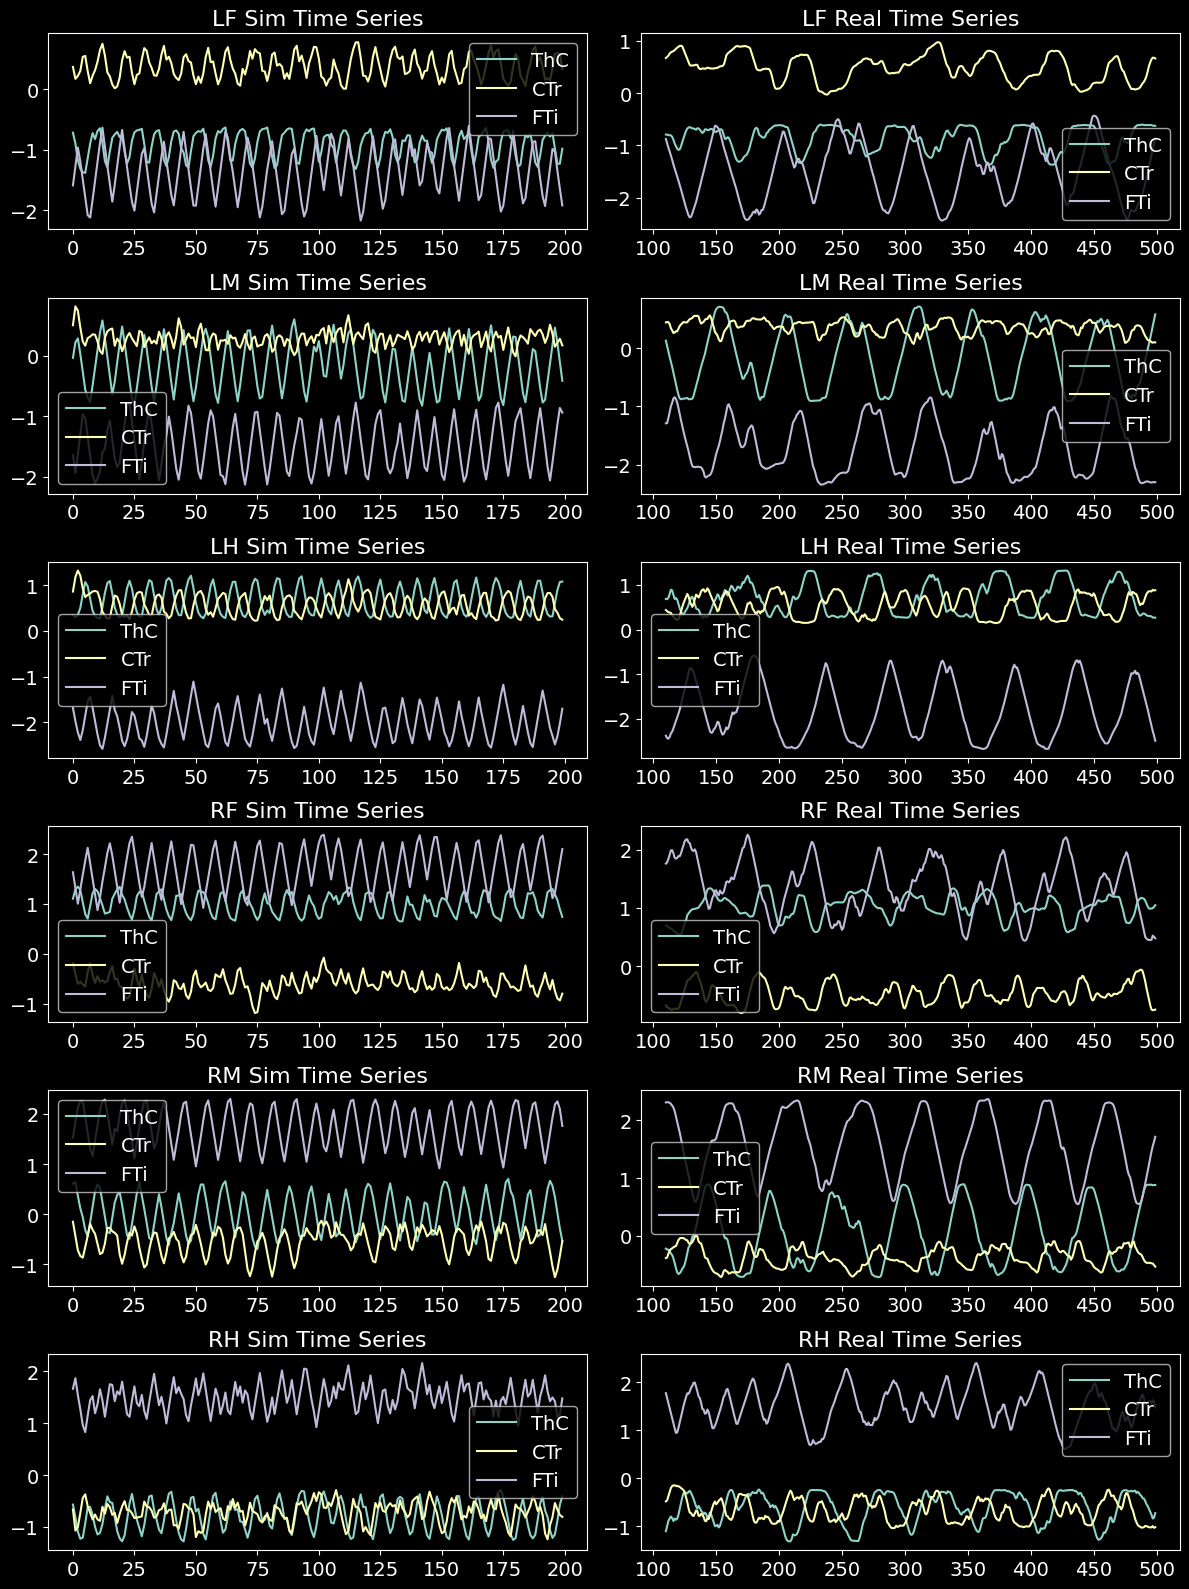

In [9]:
# plot the time series
fig, axs = plt.subplots(6, 2, figsize=(12, 16))
axs = axs.ravel()
axs[0].plot(sim_joints.index[:200], sim_joints.iloc[:200,0], label='ThC')
axs[0].plot(sim_joints.index[:200], sim_joints.iloc[:200,1], label='CTr')
axs[0].plot(sim_joints.index[:200], sim_joints.iloc[:200,2], label='FTi')
axs[0].legend(fontsize=14)
axs[0].set_title('LF Sim Time Series', fontsize =16)
axs[1].plot(real_joints.index, real_joints.iloc[:,0], label='ThC')
axs[1].plot(real_joints.index, real_joints.iloc[:,1], label='CTr')
axs[1].plot(real_joints.index, real_joints.iloc[:,2], label='FTi')
axs[1].legend(fontsize=14)
axs[1].set_title('LF Real Time Series', fontsize =16)
axs[2].plot(sim_joints.index[:200], sim_joints.iloc[:200,3], label='ThC')
axs[2].plot(sim_joints.index[:200], sim_joints.iloc[:200,4], label='CTr')
axs[2].plot(sim_joints.index[:200], sim_joints.iloc[:200,5], label='FTi')
axs[2].legend(fontsize=14)
axs[2].set_title('LM Sim Time Series', fontsize =16)
axs[3].plot(real_joints.index, real_joints.iloc[:,3], label='ThC')
axs[3].plot(real_joints.index, real_joints.iloc[:,4], label='CTr')
axs[3].plot(real_joints.index, real_joints.iloc[:,5], label='FTi')
axs[3].legend(fontsize=14)
axs[3].set_title('LM Real Time Series', fontsize =16)
axs[4].plot(sim_joints.index[:200], sim_joints.iloc[:200,6], label='ThC')
axs[4].plot(sim_joints.index[:200], sim_joints.iloc[:200,7], label='CTr')
axs[4].plot(sim_joints.index[:200], sim_joints.iloc[:200,8], label='FTi')
axs[4].legend(fontsize=14)
axs[4].set_title('LH Sim Time Series', fontsize =16)
axs[5].plot(real_joints.index, real_joints.iloc[:,6], label='ThC')
axs[5].plot(real_joints.index, real_joints.iloc[:,7], label='CTr')
axs[5].plot(real_joints.index, real_joints.iloc[:,8], label='FTi')
axs[5].legend(fontsize=14)
axs[5].set_title('LH Real Time Series', fontsize =16)

axs[6].plot(sim_joints.index[:200], sim_joints.iloc[:200,9], label='ThC')
axs[6].plot(sim_joints.index[:200], sim_joints.iloc[:200,10], label='CTr')
axs[6].plot(sim_joints.index[:200], sim_joints.iloc[:200,11], label='FTi')
axs[6].legend(fontsize=14)
axs[6].set_title('RF Sim Time Series', fontsize =16)
axs[7].plot(real_joints.index, real_joints.iloc[:,9], label='ThC')
axs[7].plot(real_joints.index, real_joints.iloc[:,10], label='CTr')
axs[7].plot(real_joints.index, real_joints.iloc[:,11], label='FTi')
axs[7].legend(fontsize=14)
axs[7].set_title('RF Real Time Series', fontsize =16)
axs[8].plot(sim_joints.index[:200], sim_joints.iloc[:200,12], label='ThC')
axs[8].plot(sim_joints.index[:200], sim_joints.iloc[:200,13], label='CTr')
axs[8].plot(sim_joints.index[:200], sim_joints.iloc[:200,14], label='FTi')
axs[8].legend(fontsize=14)
axs[8].set_title('RM Sim Time Series', fontsize =16)
axs[9].plot(real_joints.index, real_joints.iloc[:,12], label='ThC')
axs[9].plot(real_joints.index, real_joints.iloc[:,13], label='CTr')
axs[9].plot(real_joints.index, real_joints.iloc[:,14], label='FTi')
axs[9].legend(fontsize=14)
axs[9].set_title('RM Real Time Series', fontsize =16)
axs[10].plot(sim_joints.index[:200], sim_joints.iloc[:200,15], label='ThC')
axs[10].plot(sim_joints.index[:200], sim_joints.iloc[:200,16], label='CTr')
axs[10].plot(sim_joints.index[:200], sim_joints.iloc[:200,17], label='FTi')
axs[10].legend(fontsize=14)
axs[10].set_title('RH Sim Time Series', fontsize =16)
axs[11].plot(real_joints.index, real_joints.iloc[:,15], label='ThC')
axs[11].plot(real_joints.index, real_joints.iloc[:,16], label='CTr')
axs[11].plot(real_joints.index, real_joints.iloc[:,17], label='FTi')
axs[11].legend(fontsize=14)
axs[11].set_title('RH Real Time Series', fontsize =16)
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

ValueError: x and y must be the same size

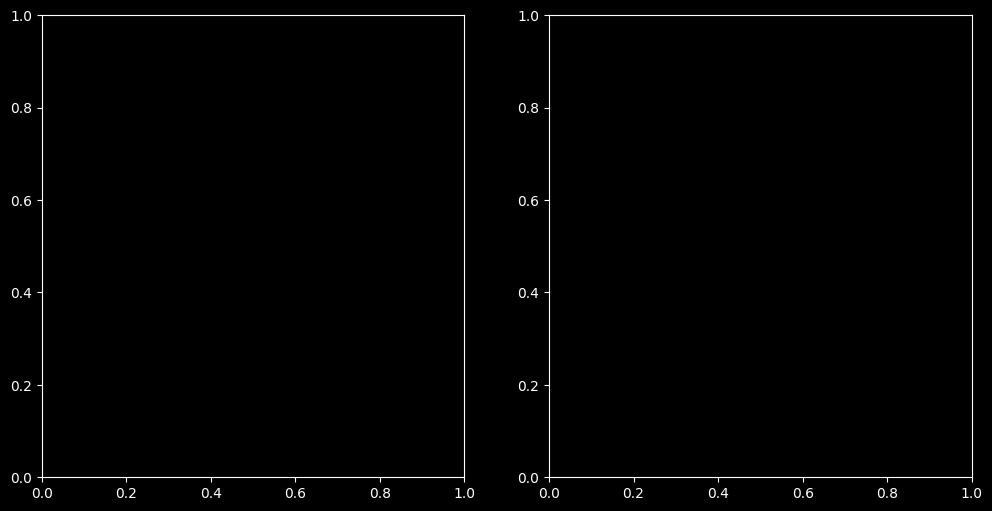

In [10]:
# plot the scatter plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs = axs.ravel()
axs[0].scatter(sim_imu.iloc[:,0], real_imu.iloc[:len(sim_imu),0], alpha=0.5)
axs[0].set_title('IMU roll Scatter Plot', fontsize =16)
axs[0].set_xlabel('Simulated IMU roll', fontsize=14)
axs[0].set_ylabel('Real IMU roll', fontsize=14)
axs[1].scatter(sim_imu.iloc[:,1], real_imu.iloc[:len(sim_imu),0], alpha=0.5)
axs[1].set_title('IMU pitch Scatter Plot', fontsize =16)
axs[1].set_xlabel('Simulated IMU pitch', fontsize=14)
axs[1].set_ylabel('Real IMU pitch', fontsize=14)
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()


**Sim to real calibration**

In [ ]:
# sim2real calibration
sim  = sim_states.iloc[:,:-6].to_numpy()
min_len = min(len(real_imu), len(real_joints))
real = np.hstack((real_imu.iloc[:min_len,:].to_numpy(), real_joints.iloc[:min_len,:].to_numpy()))
print("sim shape:", sim.shape)
print("real shape:", real.shape)

# ====== calculate for sim ======
mu_sim = sim.mean(axis=0)        
sigma_sim = sim.std(axis=0)  

# ====== calculate for real ======
mu_real = real.mean(axis=0)
sigma_real = real.std(axis=0)

# # roll: remove the outliners
# roll = real[:, 0]
# low_q = np.percentile(roll, 20)   
# high_q = np.percentile(roll, 100)  
# mask = (roll >= low_q) & (roll <= high_q)

# roll_clean = roll[mask]
# mu_roll_clean = roll_clean.mean()
# sigma_roll_clean = roll_clean.std()

# mu_real[0] = mu_roll_clean
# sigma_real[0] = sigma_roll_clean


print("mu_sim:", mu_sim)
print("sigma_sim:", sigma_sim)
print("mu_real:", mu_real)
print("sigma_real:", sigma_real)

# 保存为参数（推荐）
np.save("mu_sim.npy", mu_sim)
np.save("sigma_sim.npy", sigma_sim)
np.save("mu_real.npy", mu_real)
np.save("sigma_real.npy", sigma_real)

print("Saved calibration parameters!")

sim shape: (918, 21)
real shape: (3684, 21)
mu_sim: [ 0.12125599 -0.00646066  0.25537159 -0.91754502  0.39513893 -1.37284028
 -0.15788927  0.2761101  -1.47252343  0.70736865  0.54474246 -1.96691065
  0.97985899 -0.64503634  1.73031977 -0.00775003 -0.57508812  1.70615943
 -0.77912598 -0.73731447  1.53182852]
sigma_sim: [0.08813444 0.12594518 0.114009   0.21372331 0.19836767 0.39449062
 0.38596769 0.1304158  0.3759393  0.30426762 0.21921176 0.37318803
 0.20665865 0.19571666 0.39464601 0.36566608 0.27593286 0.38781202
 0.28348634 0.19228934 0.25762431]
mu_real: [ 0.04600383 -0.04338541 -0.21842886 -0.65888333  0.57942328 -0.48226791
  0.59291222  0.0872124  -2.25299241  0.32000628  0.854422   -2.51113692
  1.19108261 -0.63428928  0.65307261  0.76651506 -0.48898261  2.18564596
 -0.62685422 -0.71283827  2.09034769]
sigma_real: [0.06009379 0.08916835 0.08890911 0.10556377 0.1087633  0.4151543
 0.34572355 0.10662303 0.31457316 0.18521165 0.17051742 0.40203485
 0.14352143 0.10991882 0.30600738

In [ ]:
def align_state(s_real, mu_real, sigma_real, mu_sim, sigma_sim):
    sigma_real_safe = np.where(sigma_real < 1e-6, 1.0, sigma_real)
    return (s_real - mu_real) / sigma_real_safe * sigma_sim + mu_sim

# test alignment
real_calibrated = align_state(real[:min_len,:], mu_real, sigma_real, mu_sim, sigma_sim)
real_imu = real_calibrated[:, 0:3]
real_joints = real_calibrated[:, 3:21]
# convert to numpy array to pandas
real_imu = pd.DataFrame(real_imu)
real_joints = pd.DataFrame(real_joints)

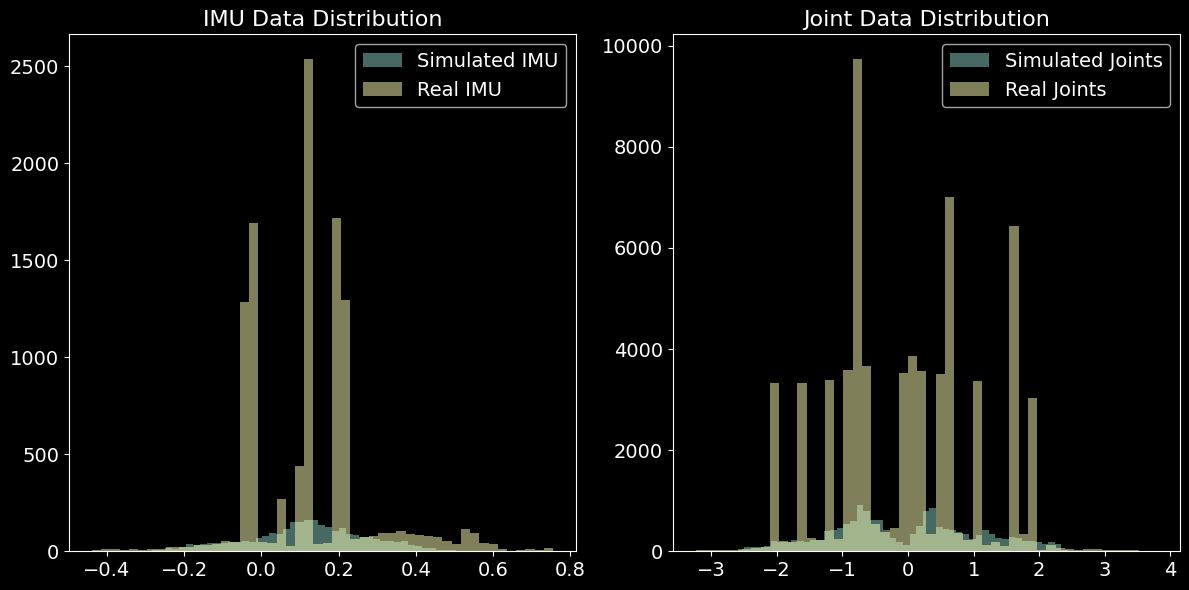

In [ ]:
# plot the histogram
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs = axs.ravel()
axs[0].hist(sim_imu.values.flatten(), bins=50, alpha=0.5, label='Simulated IMU')
axs[0].hist(real_imu.values.flatten(), bins=50, alpha=0.5, label='Real IMU')
axs[0].set_title('IMU Data Distribution', fontsize =16)
axs[0].legend(fontsize=14)
axs[1].hist(sim_joints.values.flatten(), bins=50, alpha=0.5, label='Simulated Joints')
axs[1].hist(real_joints.values.flatten(), bins=50, alpha=0.5, label='Real Joints')
axs[1].set_title('Joint Data Distribution', fontsize =16)
axs[1].legend(fontsize=14)
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

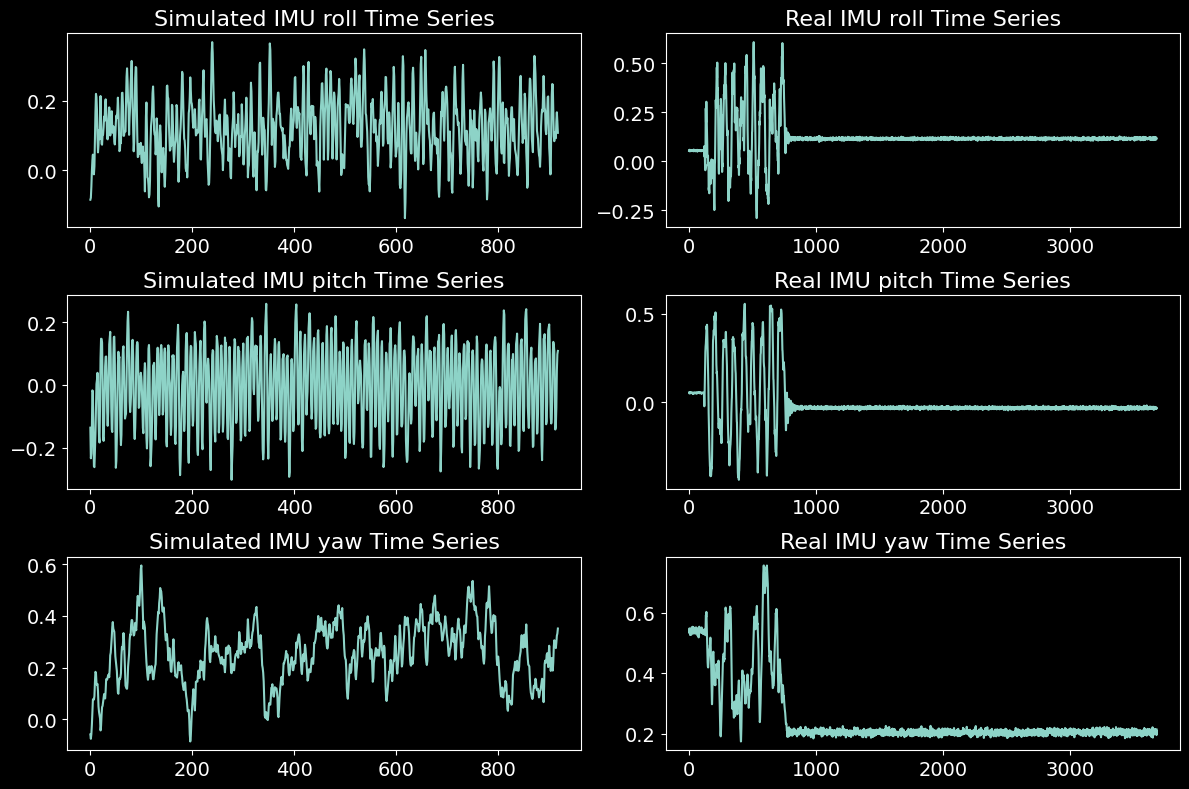

In [ ]:
# plot the time series
fig, axs = plt.subplots(3, 2, figsize=(12, 8))
axs = axs.ravel()
axs[0].plot(sim_imu.index, sim_imu.iloc[:,0])
axs[0].set_title('Simulated IMU roll Time Series', fontsize =16)
axs[1].plot(real_imu.index, real_imu.iloc[:,0])
axs[1].set_title('Real IMU roll Time Series', fontsize =16)
axs[2].plot(sim_imu.index, sim_imu.iloc[:,1])
axs[2].set_title('Simulated IMU pitch Time Series', fontsize =16)
axs[3].plot(real_imu.index, real_imu.iloc[:,1])
axs[3].set_title('Real IMU pitch Time Series', fontsize =16)
axs[4].plot(sim_imu.index, sim_imu.iloc[:,2])
axs[4].set_title('Simulated IMU yaw Time Series', fontsize =16)
axs[5].plot(real_imu.index, real_imu.iloc[:,2])
axs[5].set_title('Real IMU yaw Time Series', fontsize =16)
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()


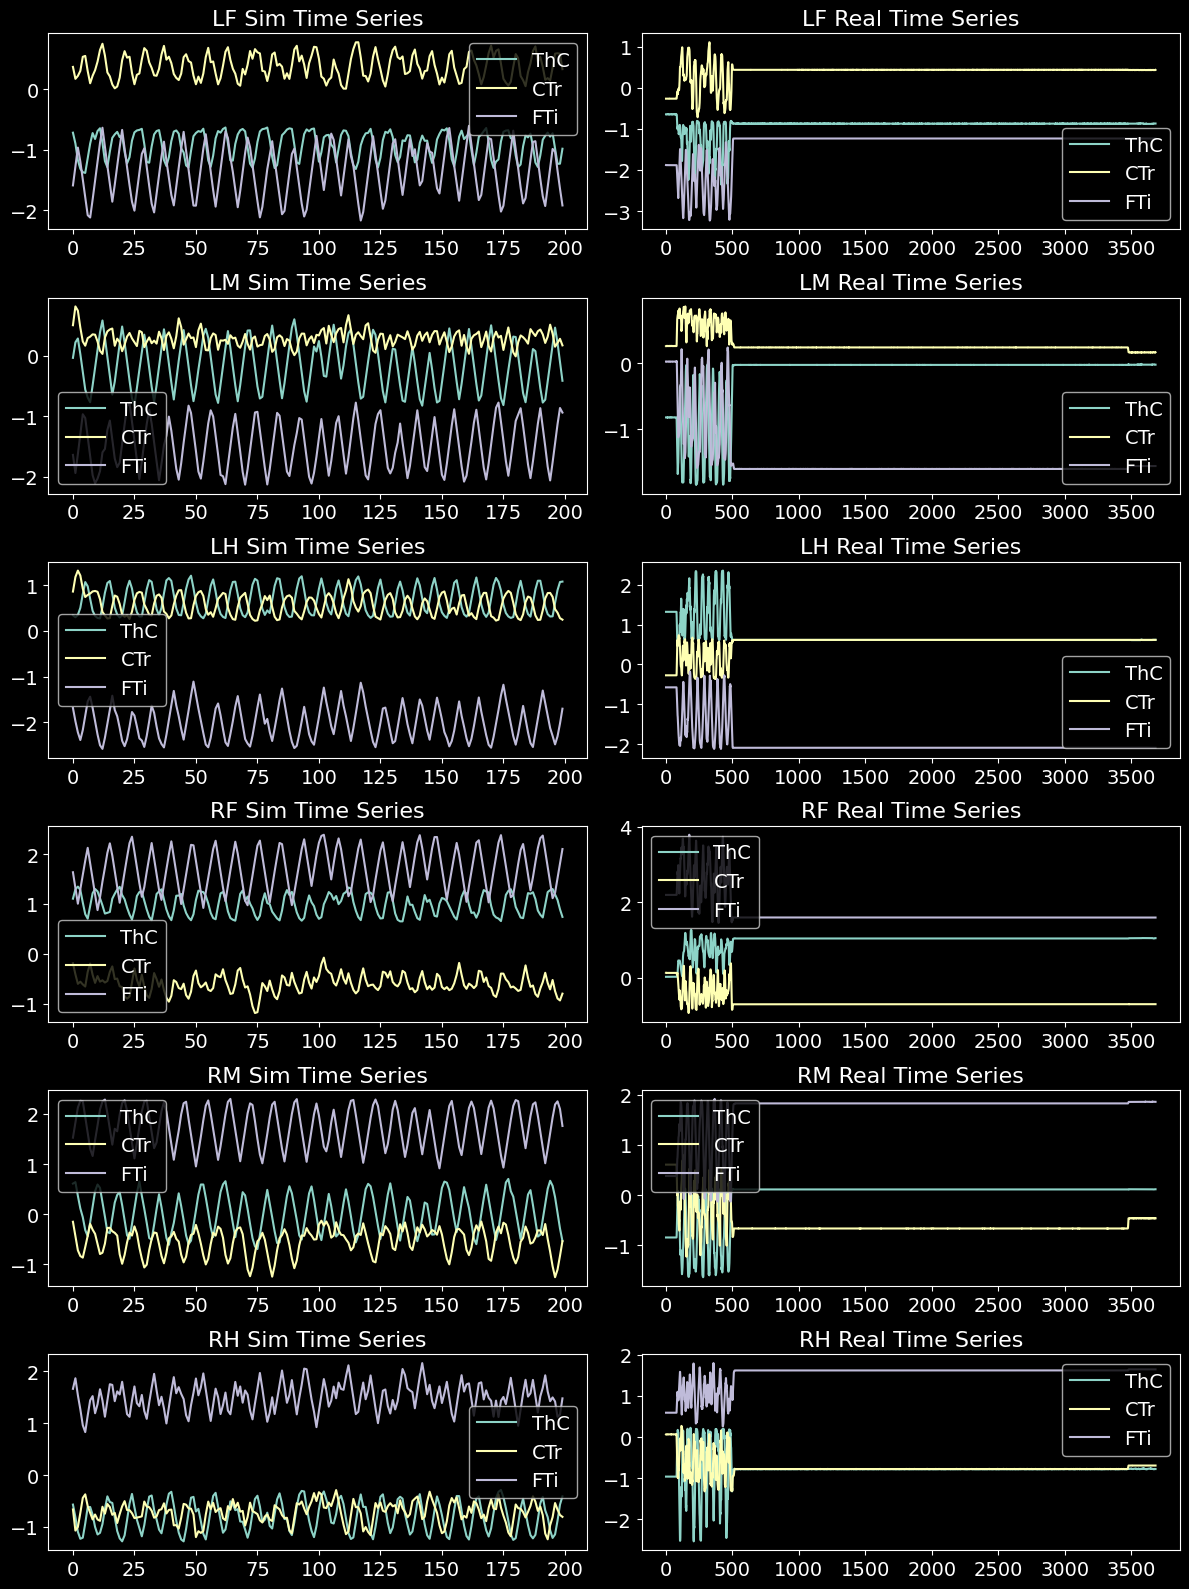

In [ ]:
# plot the time series
fig, axs = plt.subplots(6, 2, figsize=(12, 16))
axs = axs.ravel()
axs[0].plot(sim_joints.index[:200], sim_joints.iloc[:200,0], label='ThC')
axs[0].plot(sim_joints.index[:200], sim_joints.iloc[:200,1], label='CTr')
axs[0].plot(sim_joints.index[:200], sim_joints.iloc[:200,2], label='FTi')
axs[0].legend(fontsize=14)
axs[0].set_title('LF Sim Time Series', fontsize =16)
axs[1].plot(real_joints.index, real_joints.iloc[:,0], label='ThC')
axs[1].plot(real_joints.index, real_joints.iloc[:,1], label='CTr')
axs[1].plot(real_joints.index, real_joints.iloc[:,2], label='FTi')
axs[1].legend(fontsize=14)
axs[1].set_title('LF Real Time Series', fontsize =16)
axs[2].plot(sim_joints.index[:200], sim_joints.iloc[:200,3], label='ThC')
axs[2].plot(sim_joints.index[:200], sim_joints.iloc[:200,4], label='CTr')
axs[2].plot(sim_joints.index[:200], sim_joints.iloc[:200,5], label='FTi')
axs[2].legend(fontsize=14)
axs[2].set_title('LM Sim Time Series', fontsize =16)
axs[3].plot(real_joints.index, real_joints.iloc[:,3], label='ThC')
axs[3].plot(real_joints.index, real_joints.iloc[:,4], label='CTr')
axs[3].plot(real_joints.index, real_joints.iloc[:,5], label='FTi')
axs[3].legend(fontsize=14)
axs[3].set_title('LM Real Time Series', fontsize =16)
axs[4].plot(sim_joints.index[:200], sim_joints.iloc[:200,6], label='ThC')
axs[4].plot(sim_joints.index[:200], sim_joints.iloc[:200,7], label='CTr')
axs[4].plot(sim_joints.index[:200], sim_joints.iloc[:200,8], label='FTi')
axs[4].legend(fontsize=14)
axs[4].set_title('LH Sim Time Series', fontsize =16)
axs[5].plot(real_joints.index, real_joints.iloc[:,6], label='ThC')
axs[5].plot(real_joints.index, real_joints.iloc[:,7], label='CTr')
axs[5].plot(real_joints.index, real_joints.iloc[:,8], label='FTi')
axs[5].legend(fontsize=14)
axs[5].set_title('LH Real Time Series', fontsize =16)

axs[6].plot(sim_joints.index[:200], sim_joints.iloc[:200,9], label='ThC')
axs[6].plot(sim_joints.index[:200], sim_joints.iloc[:200,10], label='CTr')
axs[6].plot(sim_joints.index[:200], sim_joints.iloc[:200,11], label='FTi')
axs[6].legend(fontsize=14)
axs[6].set_title('RF Sim Time Series', fontsize =16)
axs[7].plot(real_joints.index, real_joints.iloc[:,9], label='ThC')
axs[7].plot(real_joints.index, real_joints.iloc[:,10], label='CTr')
axs[7].plot(real_joints.index, real_joints.iloc[:,11], label='FTi')
axs[7].legend(fontsize=14)
axs[7].set_title('RF Real Time Series', fontsize =16)
axs[8].plot(sim_joints.index[:200], sim_joints.iloc[:200,12], label='ThC')
axs[8].plot(sim_joints.index[:200], sim_joints.iloc[:200,13], label='CTr')
axs[8].plot(sim_joints.index[:200], sim_joints.iloc[:200,14], label='FTi')
axs[8].legend(fontsize=14)
axs[8].set_title('RM Sim Time Series', fontsize =16)
axs[9].plot(real_joints.index, real_joints.iloc[:,12], label='ThC')
axs[9].plot(real_joints.index, real_joints.iloc[:,13], label='CTr')
axs[9].plot(real_joints.index, real_joints.iloc[:,14], label='FTi')
axs[9].legend(fontsize=14)
axs[9].set_title('RM Real Time Series', fontsize =16)
axs[10].plot(sim_joints.index[:200], sim_joints.iloc[:200,15], label='ThC')
axs[10].plot(sim_joints.index[:200], sim_joints.iloc[:200,16], label='CTr')
axs[10].plot(sim_joints.index[:200], sim_joints.iloc[:200,17], label='FTi')
axs[10].legend(fontsize=14)
axs[10].set_title('RH Sim Time Series', fontsize =16)
axs[11].plot(real_joints.index, real_joints.iloc[:,15], label='ThC')
axs[11].plot(real_joints.index, real_joints.iloc[:,16], label='CTr')
axs[11].plot(real_joints.index, real_joints.iloc[:,17], label='FTi')
axs[11].legend(fontsize=14)
axs[11].set_title('RH Real Time Series', fontsize =16)
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

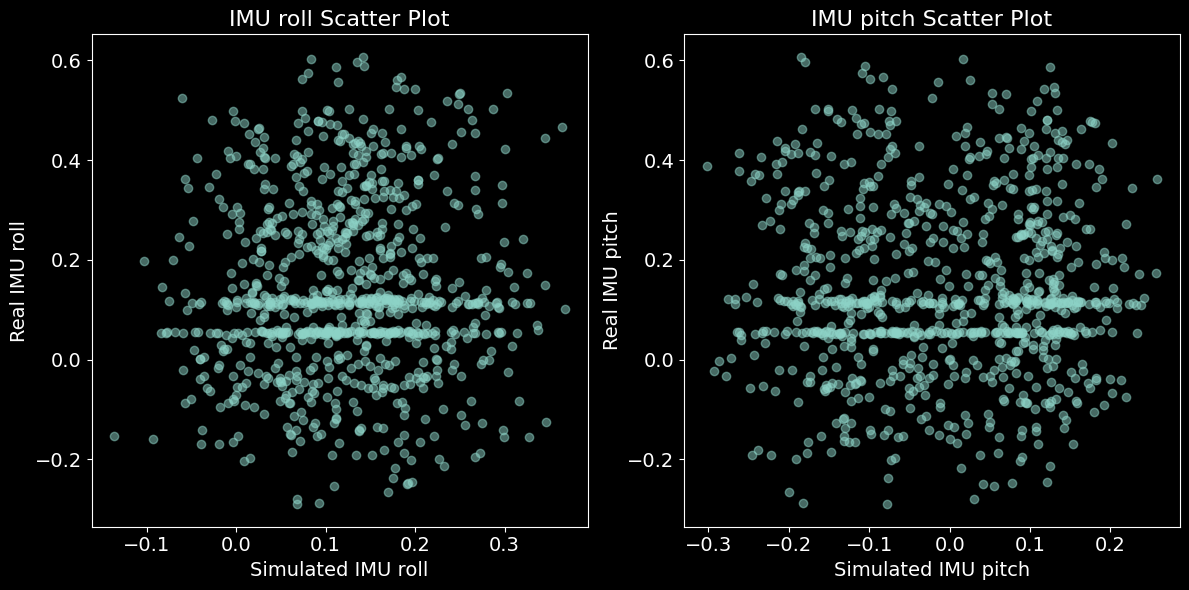

In [ ]:
# plot the scatter plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs = axs.ravel()
axs[0].scatter(sim_imu.iloc[:,0], real_imu.iloc[:len(sim_imu),0], alpha=0.5)
axs[0].set_title('IMU roll Scatter Plot', fontsize =16)
axs[0].set_xlabel('Simulated IMU roll', fontsize=14)
axs[0].set_ylabel('Real IMU roll', fontsize=14)
axs[1].scatter(sim_imu.iloc[:,1], real_imu.iloc[:len(sim_imu),0], alpha=0.5)
axs[1].set_title('IMU pitch Scatter Plot', fontsize =16)
axs[1].set_xlabel('Simulated IMU pitch', fontsize=14)
axs[1].set_ylabel('Real IMU pitch', fontsize=14)
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()
